170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/30 | Gen Loss: 2.3801 | Disc Loss: 0.5162 | Time: 23.38s


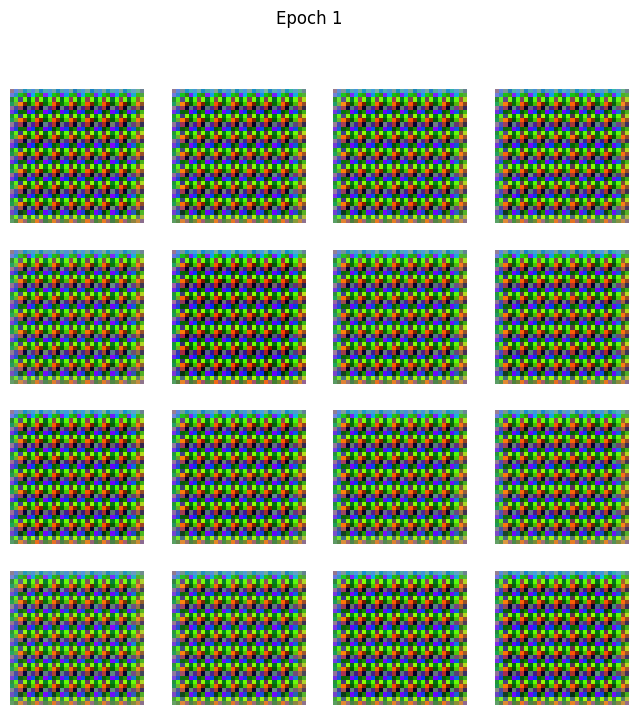

Epoch 2/30 | Gen Loss: 2.1335 | Disc Loss: 0.6032 | Time: 15.97s
Epoch 3/30 | Gen Loss: 1.3408 | Disc Loss: 1.0087 | Time: 16.02s
Epoch 4/30 | Gen Loss: 0.7043 | Disc Loss: 1.4209 | Time: 16.38s
Epoch 5/30 | Gen Loss: 0.7042 | Disc Loss: 1.4245 | Time: 16.93s


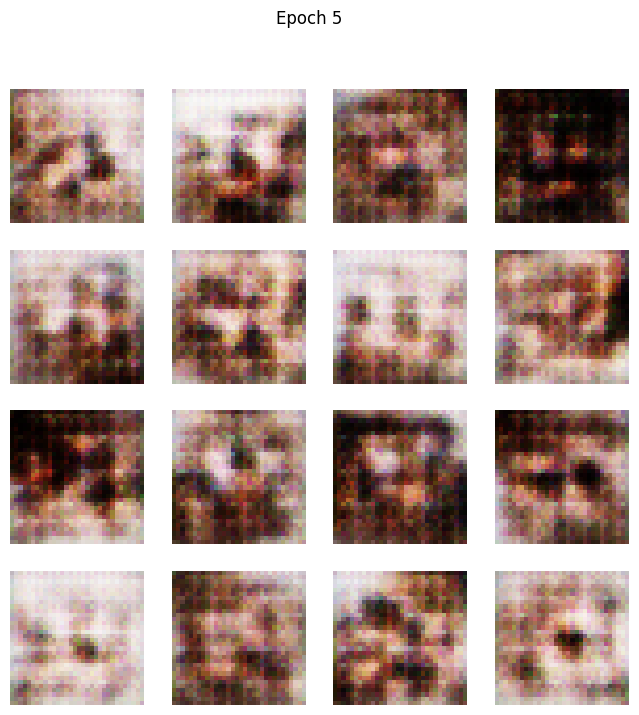

Epoch 6/30 | Gen Loss: 0.6902 | Disc Loss: 1.4225 | Time: 17.17s
Epoch 7/30 | Gen Loss: 0.6822 | Disc Loss: 1.4121 | Time: 17.55s
Epoch 8/30 | Gen Loss: 0.6879 | Disc Loss: 1.4049 | Time: 17.90s
Epoch 9/30 | Gen Loss: 0.6850 | Disc Loss: 1.4011 | Time: 17.66s
Epoch 10/30 | Gen Loss: 0.6892 | Disc Loss: 1.3968 | Time: 17.35s


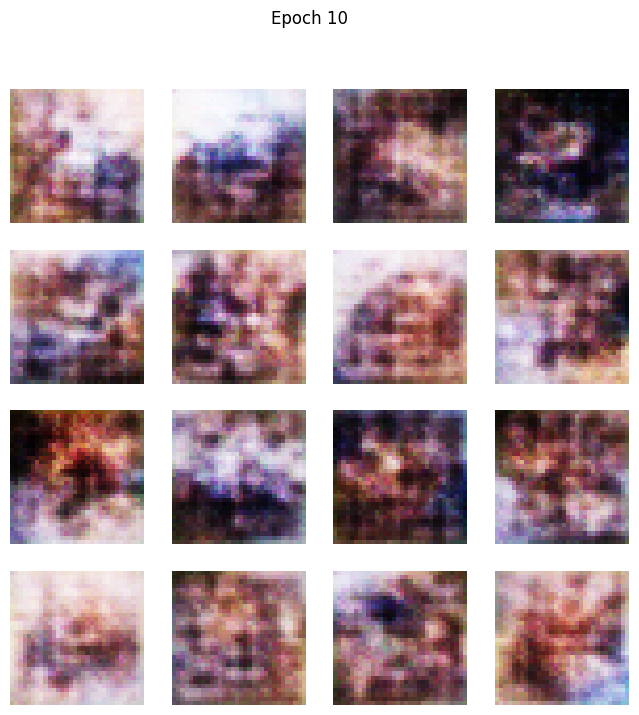

Epoch 11/30 | Gen Loss: 0.6907 | Disc Loss: 1.3937 | Time: 17.44s
Epoch 12/30 | Gen Loss: 0.6914 | Disc Loss: 1.3901 | Time: 17.52s
Epoch 13/30 | Gen Loss: 0.6917 | Disc Loss: 1.3901 | Time: 17.63s
Epoch 14/30 | Gen Loss: 0.6933 | Disc Loss: 1.3866 | Time: 17.44s
Epoch 15/30 | Gen Loss: 0.7039 | Disc Loss: 1.3850 | Time: 17.50s


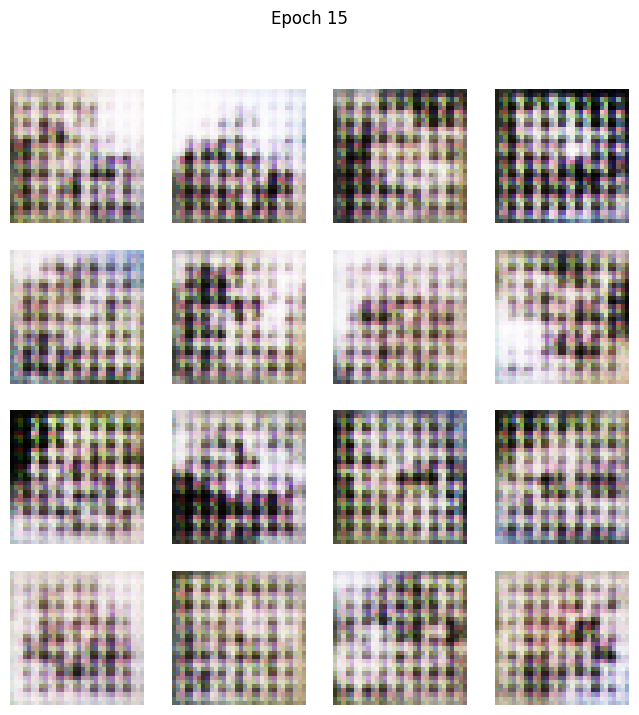

Epoch 16/30 | Gen Loss: 0.6960 | Disc Loss: 1.3851 | Time: 17.49s
Epoch 17/30 | Gen Loss: 0.7275 | Disc Loss: 1.3673 | Time: 17.54s
Epoch 18/30 | Gen Loss: 0.6848 | Disc Loss: 1.3882 | Time: 17.48s
Epoch 19/30 | Gen Loss: 0.7049 | Disc Loss: 1.3838 | Time: 17.53s
Epoch 20/30 | Gen Loss: 0.6935 | Disc Loss: 1.3876 | Time: 17.57s


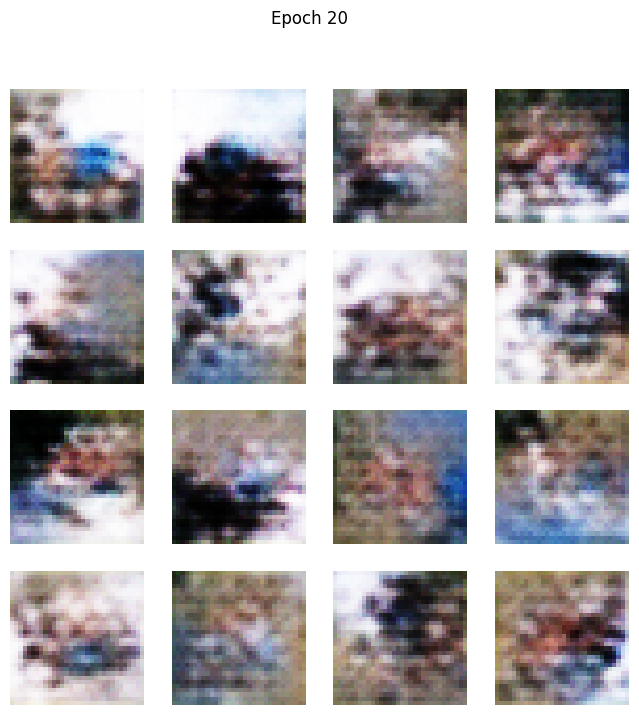

Epoch 21/30 | Gen Loss: 0.6979 | Disc Loss: 1.3887 | Time: 17.56s
Epoch 22/30 | Gen Loss: 0.7005 | Disc Loss: 1.3874 | Time: 17.58s
Epoch 23/30 | Gen Loss: 0.7015 | Disc Loss: 1.3859 | Time: 17.48s
Epoch 24/30 | Gen Loss: 0.7004 | Disc Loss: 1.3868 | Time: 17.55s
Epoch 25/30 | Gen Loss: 0.7034 | Disc Loss: 1.3841 | Time: 17.54s


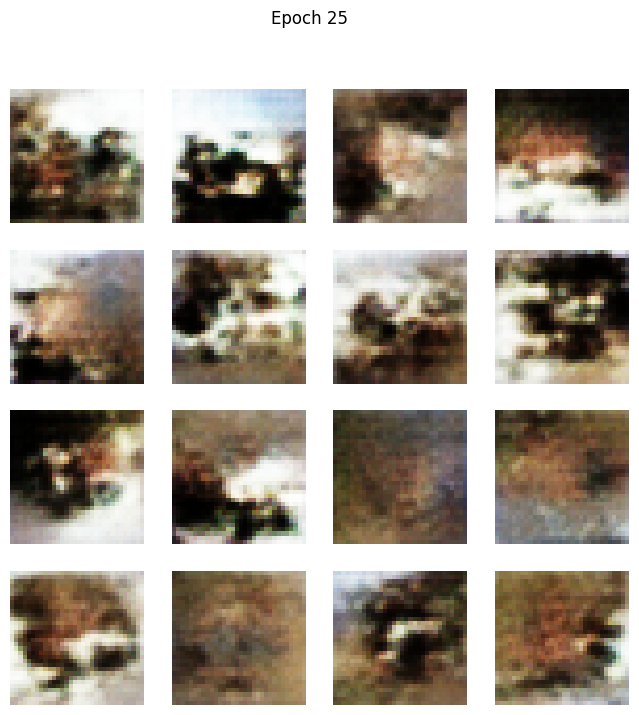

Epoch 26/30 | Gen Loss: 0.7076 | Disc Loss: 1.3773 | Time: 17.59s
Epoch 27/30 | Gen Loss: 0.7035 | Disc Loss: 1.3848 | Time: 17.42s
Epoch 28/30 | Gen Loss: 0.7036 | Disc Loss: 1.3796 | Time: 17.54s
Epoch 29/30 | Gen Loss: 0.7007 | Disc Loss: 1.3819 | Time: 17.52s
Epoch 30/30 | Gen Loss: 0.7117 | Disc Loss: 1.3733 | Time: 17.61s


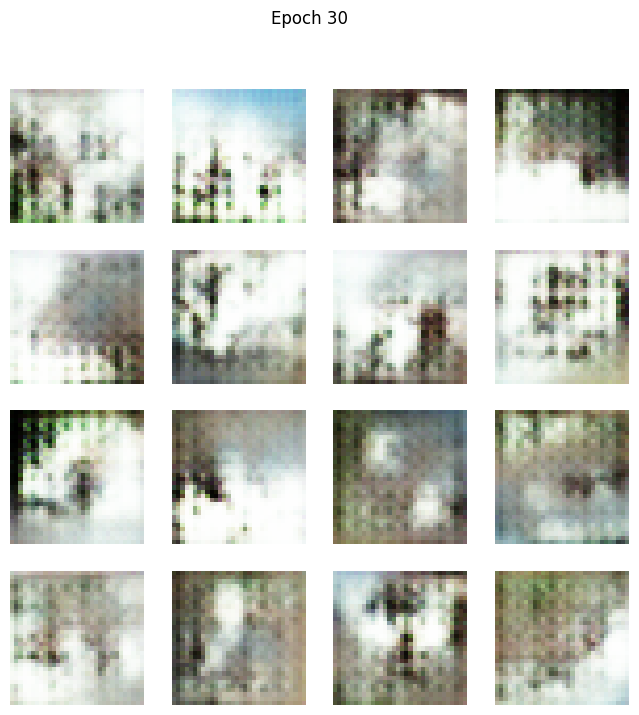

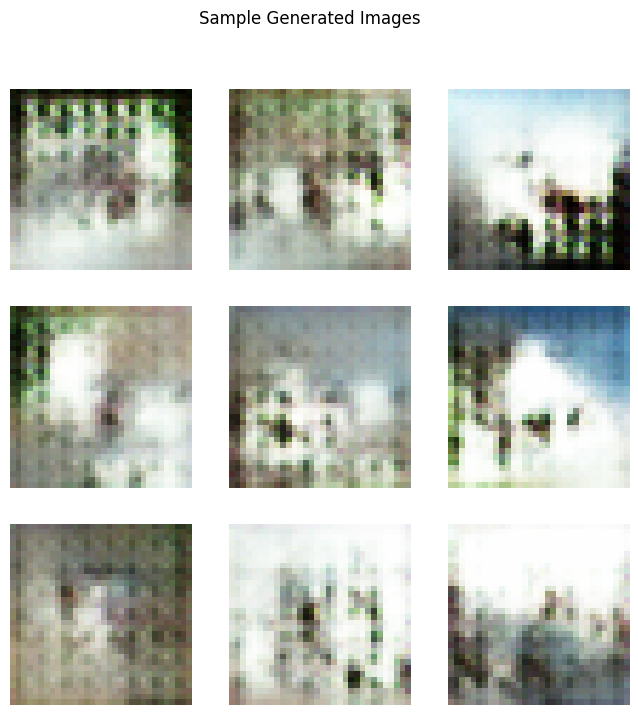

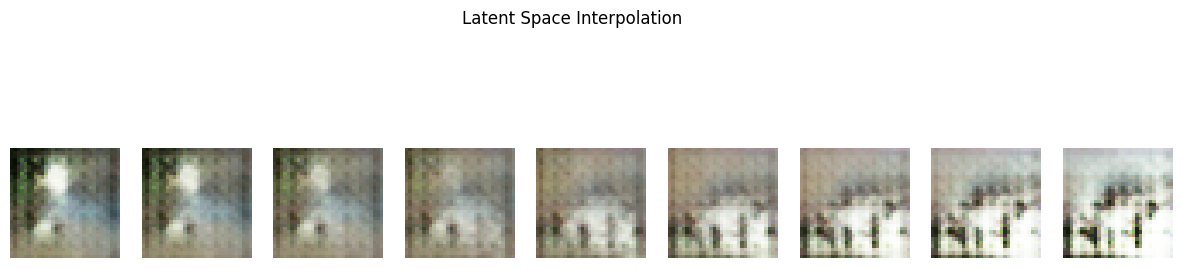

Saved: dcgan_generator.keras


In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import time

# =========================
# CONFIG
# =========================
LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS = 30
IMG_SHAPE = (32, 32, 3)

# =========================
# LOAD DATA
# =========================
(x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5  # [-1, 1]

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(50000)
    .batch(BATCH_SIZE, drop_remainder=True)
)

# =========================
# GENERATOR
# =========================
def make_generator():
    return tf.keras.Sequential([
        layers.Input(shape=(LATENT_DIM,)),
        layers.Dense(8 * 8 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Reshape((8, 8, 256)),
        layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(3, 3, strides=1, padding="same", use_bias=False, activation="tanh")
    ])

# =========================
# DISCRIMINATOR
# =========================
def make_discriminator():
    return tf.keras.Sequential([
        layers.Input(shape=IMG_SHAPE),
        layers.Conv2D(64, 4, strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Conv2D(128, 4, strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1)
    ])

generator = make_generator()
discriminator = make_discriminator()

# =========================
# LOSS + OPTIMIZER
# =========================
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

# =========================
# TRAIN STEP
# =========================
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return gen_loss, disc_loss

# =========================
# DISPLAY FUNCTION
# =========================
def show_images(model, test_input, title="Generated Images"):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(8, 8))
    for i in range(predictions.shape[0]):
        plt.subplot(int(np.sqrt(predictions.shape[0])), int(np.sqrt(predictions.shape[0])), i + 1)
        img = (predictions[i] + 1) / 2.0
        plt.imshow(img.numpy())
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

# =========================
# TRAIN
# =========================
seed = tf.random.normal([16, LATENT_DIM])

for epoch in range(EPOCHS):
    start = time.time()
    gen_losses, disc_losses = [], []

    for image_batch in train_dataset:
        g_loss, d_loss = train_step(image_batch)
        gen_losses.append(g_loss.numpy())
        disc_losses.append(d_loss.numpy())

    print(f"Epoch {epoch+1}/{EPOCHS} | Gen Loss: {np.mean(gen_losses):.4f} | Disc Loss: {np.mean(disc_losses):.4f} | Time: {time.time()-start:.2f}s")

    if (epoch + 1) % 5 == 0 or epoch == 0:
        show_images(generator, seed, title=f"Epoch {epoch+1}")

# =========================
# SAMPLE IMAGES
# =========================
sample_noise = tf.random.normal([9, LATENT_DIM])
show_images(generator, sample_noise, title="Sample Generated Images")

# =========================
# LATENT INTERPOLATION
# =========================
def interpolate(z1, z2, steps=9):
    ratios = np.linspace(0, 1, steps)
    vectors = []
    for r in ratios:
        vectors.append((1 - r) * z1 + r * z2)
    return tf.concat(vectors, axis=0)

z1 = tf.random.normal([1, LATENT_DIM])
z2 = tf.random.normal([1, LATENT_DIM])
interp_vectors = interpolate(z1, z2, steps=9)
interp_images = generator(interp_vectors, training=False)

plt.figure(figsize=(15, 4))
for i in range(interp_images.shape[0]):
    plt.subplot(1, 9, i + 1)
    img = (interp_images[i] + 1) / 2.0
    plt.imshow(img.numpy())
    plt.axis("off")
plt.suptitle("Latent Space Interpolation")
plt.show()

# =========================
# SAVE MODEL
# =========================
generator.save("dcgan_generator.keras")
print("Saved: dcgan_generator.keras")